In [59]:
import pandas as pd, numpy as np
from scipy.spatial.distance import squareform, pdist, cdist
from sklearn.neighbors import kneighbors_graph, NearestNeighbors
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import shortest_path, connected_components
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, gaussian_kde
from sklearn.decomposition import PCA
import dcor
import joblib

from sklearn.neighbors import KernelDensity

import plot_style as ps

In [2]:
def diffusion_map(data, eps, alpha=1, k=4):
    Dsq = squareform(pdist(data)**2)
    Wm = np.exp(-Dsq/eps); q = Wm.sum(1)
    Wa = Wm/np.outer(q**alpha, q**alpha)
    da = Wa.sum(1); Dis = 1.0/np.sqrt(da)
    S = Dis[:, None]*Wa*Dis[None, :]                
    w, v = np.linalg.eigh(S)
    idx = np.argsort(w)[::-1]; w, v = w[idx], v[:, idx]
    phi = Dis[:, None]*v                             
    Psi = phi[:, 1:k+1]*w[1:k+1]                     
    return {"evals": w, "Psi": Psi, "phi": phi, "W": Wm, "degrees": q}

def reconstruct_path(pred, start, end):
    path = [end]; current = end
    while current != start:
        current = pred[start, current]
        if current == -9999: return None
        path.append(current)
    return path[::-1]

def graph_degree_density(Psi, h):
    Dsq = squareform(pdist(Psi)**2)
    rho = np.exp(-Dsq/h).sum(1)
    scale = rho.mean(); rho /= scale
    rho = np.maximum(rho, 1e-6)
    return rho, -np.log(rho), scale

def density_and_bandwidth(Psi, multiplier=0.1):
    N = Psi.shape[0]
    median_Dsq = np.median(squareform(pdist(Psi)**2)[np.triu_indices(N,1)])
    h = multiplier * median_Dsq
    return h, median_Dsq, graph_degree_density(Psi, h)

def density_aware_cost(A_dist_sym, V, beta):
    rows, cols = A_dist_sym.nonzero()
    base = np.asarray(A_dist_sym[rows, cols]).ravel()
    costs = base*np.exp(beta*(V[rows]+V[cols])/2)
    return csr_matrix((costs, (rows, cols)), shape=A_dist_sym.shape)

def graph_path(A_dist_sym, beta, V, start, end):
    A = density_aware_cost(A_dist_sym, V, beta)
    _, pred = shortest_path(A, directed=False, return_predecessors=True)
    return reconstruct_path(pred, start, end)

def linear_path(Psi, start_idx, end_idx, n_grid=10):
    return np.linspace(Psi[start_idx], Psi[end_idx], num=n_grid)

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query /= scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=27, tau=0.2):
    nn = NearestNeighbors(n_neighbors=m); nn.fit(Psi)
    distances, indices = nn.kneighbors(gamma)
    a = np.exp(-distances**2/tau) / np.sum(np.exp(-distances**2 / tau), axis=1, keepdims=True)
    points = Z[indices, :]; z_hat = np.sum(a[:, :, None] * points, axis=1)
    z_hat[0], z_hat[-1] = Z[start_idx], Z[end_idx]
    return z_hat

def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1); nn.fit(Z)
    dNN, _ = nn.kneighbors(z_hat)
    return dNN

def latent_path_length(coords):
    diffs = np.diff(coords, axis=0)
    return np.linalg.norm(diffs, axis=1).sum()

def path_smoothness(coords):
    if len(coords) < 3:
        return 0.0
    second_diff = coords[2:] - 2 * coords[1:-1] + coords[:-2]
    return np.sum(np.linalg.norm(second_diff, axis=1) ** 2)

def density_weighted_cost(coords, V_path, beta):
    diffs = np.diff(coords, axis=0)
    edge_lengths = np.linalg.norm(diffs, axis=1)
    V_mid = 0.5 * (V_path[:-1] + V_path[1:])
    return np.sum(edge_lengths * np.exp(beta * V_mid))

def direction_change(coords):
    d = np.diff(coords, axis=0)
    u = d / np.linalg.norm(d, axis=1)[:, None]
    return np.sum( np.linalg.norm(np.diff(u, axis=0), axis=1)**2 )

def lin_interior_min_mean(Psi, s, e, h, scale, n=40):
    lin = np.linspace(Psi[s], Psi[e], n)[1:-1]
    rho_lin, _ = latent_density_at_points(lin, Psi, h, scale)
    return rho_lin.min(), rho_lin.mean(), nn_dist_to_cloud(Psi, lin).max(), np.argmin(rho_lin)

def nn_dist_to_cloud(Psi, pts):
    return np.array([np.min(np.linalg.norm(Psi - p, axis=1)) for p in pts])

def latent_density_at_points(gamma, Psi, h, scale):
    Dsq_query = cdist(gamma, Psi, metric="sqeuclidean")
    rho_query = np.exp(-Dsq_query / h).sum(axis=1)
    rho_query = rho_query/scale
    rho_query_floor = np.maximum(rho_query, 1e-6)
    V_query = -np.log(rho_query_floor)
    return rho_query_floor, V_query

def interior_min_mean(rho, idx_path):
    interior = idx_path[1:-1] if len(idx_path) > 2 else idx_path
    return rho[interior].min(), rho[interior].mean()

In [3]:
K_GRAPH = 15
BETA = 1.5
N_DIFFUSION_COORDS = 4
EPS_DIFFUSION = 3
N_LINEAR_GRID = 40
M_LIFT = 22

endpoint_pairs = {"2006 benign -> 2008 GFC": ("2006-03-01", "2008-10-01"), "2019 benign -> 2020 COVID": ("2019-07-01", "2020-04-01"), 
                  "2019 benign -> 2021 Fiscal Tightening": ("2019-04-01", "2022-04-01"), "1977 benign -> 1982 Recession Trough": ("1977-01-01", "1982-07-01")}

In [4]:
df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
dates = df.index; variables = df.columns[:-1]
Z = df.to_numpy()[:, :-1]; N = Z.shape[0]

obs_df = pd.read_parquet("./datasets/transformed_observed_df.parquet").loc[dates]
Z_real = obs_df[variables].to_numpy()

pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

In [5]:
diff = diffusion_map(Z, EPS_DIFFUSION, k=N_DIFFUSION_COORDS)
Psi = diff["Psi"]

h_dens, med_Dsq, (rho, V, scale) = density_and_bandwidth(Psi)

A_dist = kneighbors_graph(Psi, n_neighbors=K_GRAPH, mode="distance", include_self=False)
A_dist_sym = A_dist.maximum(A_dist.T)

# Phase 8: Robustness checks
### (i) Vary $k$ in the graph construction

In [6]:
rows = []

for name, (s, e) in pairs.items():
    
    ks = [5, 10, 15, 20, 25, 30]
    for k in ks:
        A_dist_k = kneighbors_graph(Psi, n_neighbors=k, mode="distance", include_self=False)
        A_dist_sym_k = A_dist_k.maximum(A_dist_k.T)
        p = graph_path(A_dist_sym_k, BETA, V, s, e)
        P = Psi[p]; V_path = V[p]
        imin, imean = interior_min_mean(rho, p)

        rows.append({"k": k, "event": name, "number_points": P.shape[0], "interior_minimum_density": imin, "interior_mean_density": imean,
                     "latent_path_length": latent_path_length(P), "density_weighted_cost": density_weighted_cost(P, V_path, beta=BETA), 
                     "smoothness": path_smoothness(P), "direction_change": direction_change(P)})

knn_res = pd.DataFrame(rows)
print(knn_res.round(4).to_string(index=False))

 k                                 event  number_points  interior_minimum_density  interior_mean_density  latent_path_length  density_weighted_cost  smoothness  direction_change
 5               2006 benign -> 2008 GFC             14                    0.1048                 1.4123              1.2338                42.4750      0.3633            7.0260
10               2006 benign -> 2008 GFC             10                    0.1640                 1.1750              1.2182                32.3068      0.5017            7.4463
15               2006 benign -> 2008 GFC              8                    0.2133                 1.3090              1.1473                26.3494      0.4252            4.8811
20               2006 benign -> 2008 GFC              7                    0.2458                 1.3964              1.0952                24.2899      0.4322            2.8567
25               2006 benign -> 2008 GFC              7                    0.2889                 1.5238      

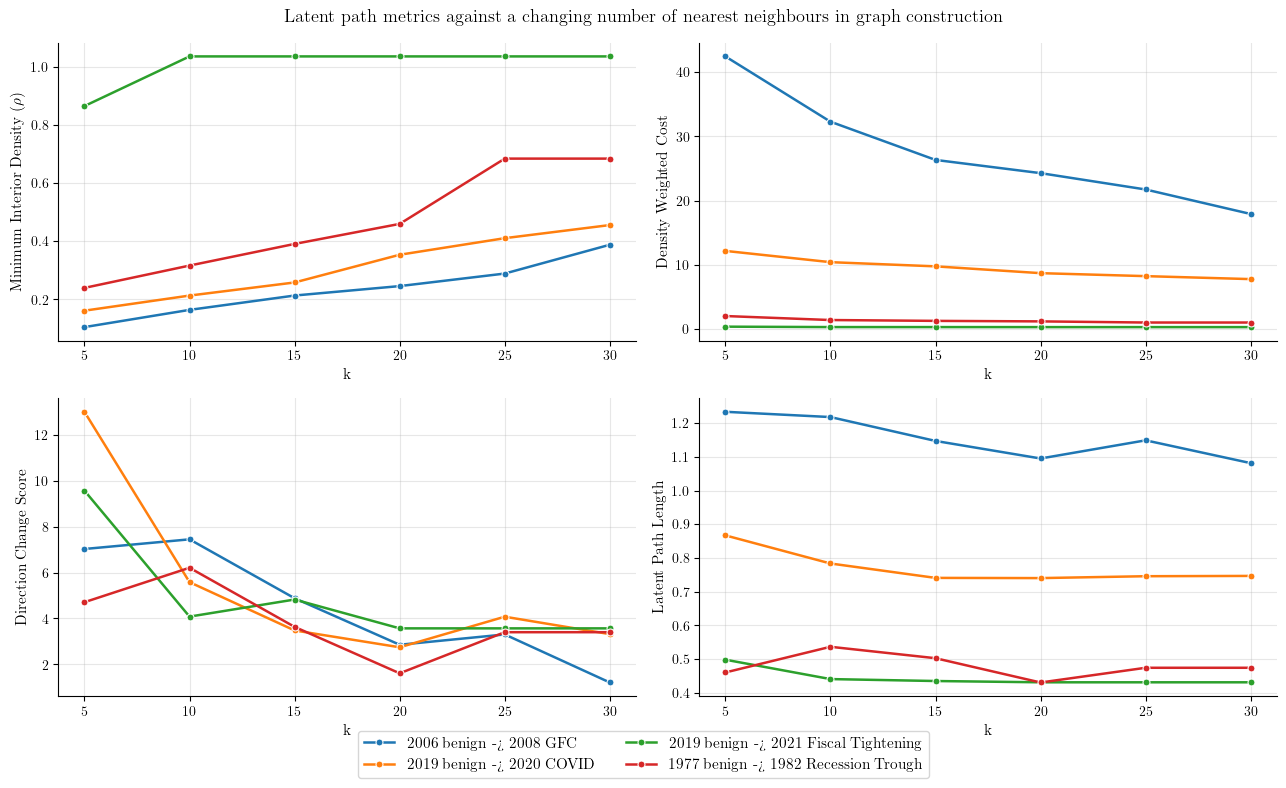

In [18]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['interior_minimum_density', 'density_weighted_cost', 'direction_change', 'latent_path_length']

metric_names_clean = {
    "interior_minimum_density": r"Minimum Interior Density ($\rho$)",
    "density_weighted_cost": "Density Weighted Cost",
    "direction_change": "Direction Change Score",
    "latent_path_length": "Latent Path Length"}

for i, metric in enumerate(metrics):
    sns.lineplot(data=knn_res, x='k', y=metric, hue='event', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig("./figures/robustness_k.pdf")
plt.show()

### (ii) Vary $\beta$

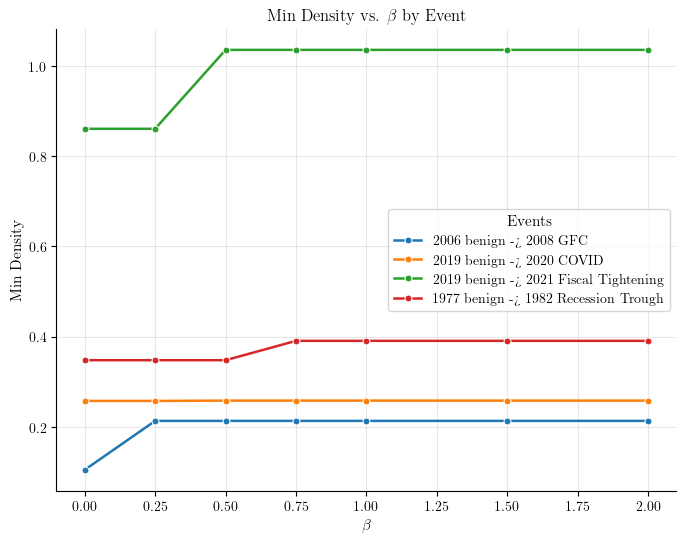

In [8]:
beta_records = []
betas = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0]

for event, (start_idx, end_idx) in pairs.items():
    for beta in betas:
        idx_graph = graph_path(A_dist_sym, beta=beta, V=V, start=start_idx, end=end_idx)
        if len(idx_graph) > 2:
            interior_density = rho[idx_graph][1:-1]
        else:
            interior_density = rho[idx_graph]
        beta_records.append({"event": event, "beta": beta, "min_density": interior_density.min(), "mean_density": interior_density.mean()})

beta_df = pd.DataFrame(beta_records)
plt.figure(figsize=(8,6))
sns.lineplot(data=beta_df, x='beta', y='min_density', hue='event', marker='o', palette='tab10')

plt.xlabel(r'$\beta$'); plt.ylabel('Min Density')
plt.title(r'Min Density vs. $\beta$ by Event')
plt.legend(title='Events'); plt.grid(alpha=0.3)
plt.show()

### (iii) Vary the diffusion bandwidth slightly

In [56]:
eps_values = [0.1, 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
path_rows = []; embedding_rows = []; paths_eps = []; embedding_store = {}
path_settings = {"ordinary graph": 0.0, "density-aware graph": BETA}

for eps in eps_values:
    # Recompute diffusion embedding
    diff_eps = diffusion_map(Z, eps=eps, k=N_DIFFUSION_COORDS)
    Psi_eps = diff_eps["Psi"]; evals = diff_eps["evals"]
    h_dens, med_Dsq, density_output = density_and_bandwidth(Psi_eps, multiplier=0.1)
    rho_eps, V_eps, scale_eps = density_output

    # Construct kNN graph
    A_dist_eps = kneighbors_graph(Psi_eps, n_neighbors=K_GRAPH, mode="distance", include_self=False)
    A_dist_sym_eps = A_dist_eps.maximum(A_dist_eps.T)
    n_components = connected_components(A_dist_sym_eps, directed=False, return_labels=False)
    degree = np.asarray((A_dist_sym_eps > 0).sum(axis=1)).ravel()
    edge_lengths = A_dist_sym_eps.data
    median_edge_length = np.median(edge_lengths)
    max_edge_length = np.max(edge_lengths)

    # Gap after the retained non-trivial coordinates
    spectral_gap_m1 = (evals[N_DIFFUSION_COORDS - 1] - evals[N_DIFFUSION_COORDS])
    spectral_gap = (evals[N_DIFFUSION_COORDS] - evals[N_DIFFUSION_COORDS + 1])
    spectral_gap_p1 = (evals[N_DIFFUSION_COORDS + 1] - evals[N_DIFFUSION_COORDS + 2])

    embedding_rows.append({"eps": eps, "lambda_1": evals[1], "lambda_2": evals[2], "lambda_3": evals[3],
                           "spectral_gap": spectral_gap, "spectral_gap_p1": spectral_gap_p1, "spectral_gap_m1": spectral_gap_m1,
                           "connected_components": n_components, "mean_degree": degree.mean(), "median_edge_length": median_edge_length,
                           "max_edge_length": max_edge_length, "density_bandwidth": h_dens})
    embedding_store[eps] = {"Psi": Psi_eps, "rho": rho_eps, "V": V_eps, "A_dist_sym": A_dist_sym_eps}

    # Compute paths for every event
    for event, (start_idx, end_idx) in pairs.items():
        for path_type, beta in path_settings.items():
            idx_path = graph_path(A_dist_sym_eps, beta=beta, V=V_eps, start=start_idx, end=end_idx)
            coords = Psi_eps[idx_path]; path_density = rho_eps[idx_path]; V_path = V_eps[idx_path]
            if len(path_density) > 2:
                interior_density = path_density[1:-1]
            else:
                interior_density = path_density

            path_length = latent_path_length(coords)
            path_rows.append({"eps": eps, "event": event, "path_type": path_type, "number_points": len(idx_path), "interior_minimum_density": interior_density.min(),
                              "interior_mean_density": interior_density.mean(), "latent_path_length": path_length, "normalised_path_length": (path_length / median_edge_length),
                              "density_weighted_cost": density_weighted_cost(coords, V_path, beta=beta), "smoothness": path_smoothness(coords), "direction_change": direction_change(coords)})
            
            paths_eps.append({"eps": eps, "event": event, "path_type": path_type, "path_idx": idx_path, "coords": coords, "density": path_density, "V": V_path})

In [10]:
eps_path_df = pd.DataFrame(path_rows)
eps_path_df["event_label"] = eps_path_df["event"].str.replace("->", r"$\rightarrow$")
eps_embedding_df = pd.DataFrame(embedding_rows)

print("Embedding and graph diagnostics")
print(eps_embedding_df.drop(["spectral_gap_m1", "spectral_gap_p1"], axis=1).round(4).to_string(index=False))

Embedding and graph diagnostics
 eps  lambda_1  lambda_2  lambda_3  spectral_gap  connected_components  mean_degree  median_edge_length  max_edge_length  density_bandwidth
 0.1    1.0000    1.0000    1.0000        0.0000                     1      23.9758              0.0000           0.7441             0.0000
 0.5    0.9991    0.9985    0.9980        0.0001                     1      20.1615              0.0002           0.9992             0.0000
 1.0    0.9298    0.9104    0.8924        0.0051                     1      19.3513              0.0054           1.0625             0.0002
 2.0    0.6012    0.5731    0.4714        0.0330                     1      18.9771              0.0351           1.5817             0.0035
 2.5    0.5048    0.4447    0.3202        0.0222                     1      19.1602              0.0493           1.3215             0.0049
 3.0    0.4336    0.3693    0.2331        0.0117                     1      19.3674              0.0690           0.7379        

This is what made me rethink the initial choice of embedding dimension. We see here that $\varepsilon=2$ gives the biggest jump at this dimension ($r=3$). For $r=2$, we have $\varepsilon=3$ is the correct choice, but this doesn't line up with what we have done so far.

Aside from that, the results look quite stable. `mean_degree` is very stable for $\varepsilon \ge 1$. The edge length metrics are also quite stable, small $\varepsilon$ means that the adjacency matrix is nearly diagnoal and the diffusion operator is split into lots of weakly communicating regions. Then lots of these points get very similar coordinates in the diffusion mapping, leading to a very low median edge length. Increasing $\varepsilon$ means that there is not diversity in the regions and the eigenvalues begin to differentiate. Then the points in the diffusion mapping are further away. For large $\varepsilon$ the weights are more uniformly distributed, there is not as much diversity since lots of terms become nearly 1 under $\exp(-\frac{\|x_i-x_j\|^2}{\varepsilon})$. Then there emerge no important eigendirections, meaning that each eigenvalue becomes small and uniform, then the diffusion coordinates $(\lambda_1\phi_1, \lambda_2\phi_2, \lambda_3\phi_3)$ all become small and therefore the edge lengths decrease in diffusion space.

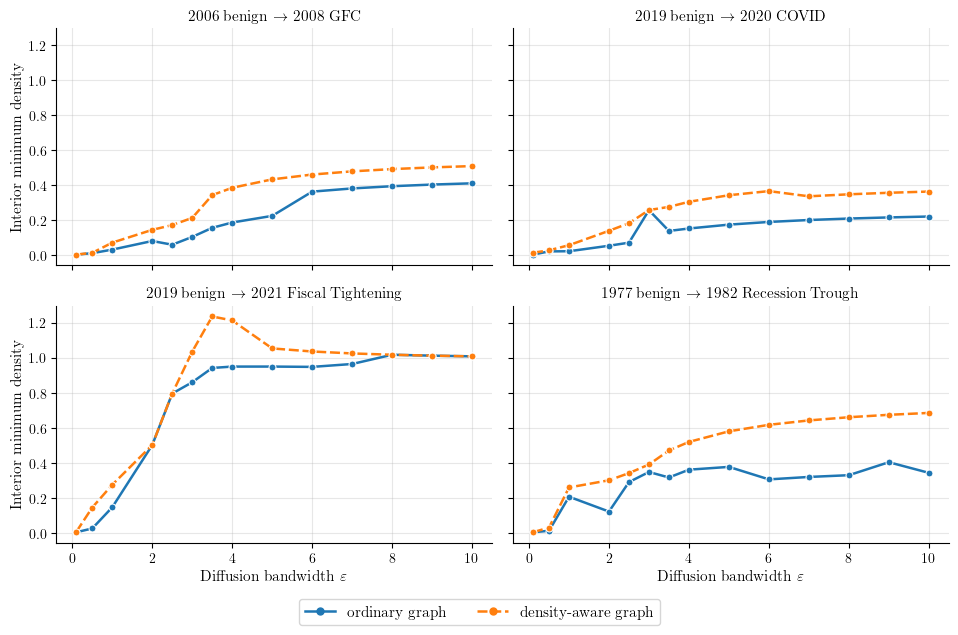

In [11]:
g = sns.relplot(data=eps_path_df, x="eps", y="interior_minimum_density", hue="path_type", style="path_type",
                col="event_label",col_wrap=2, kind="line", marker="o", height=3.2, aspect=1.25)

g.set_axis_labels(r"Diffusion bandwidth $\varepsilon$", "Interior minimum density")
g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.grid(alpha=0.3)

handles = g._legend.legend_handles
labels = [text.get_text() for text in g._legend.texts]

g._legend.remove()

g.figure.legend(handles=handles, labels=labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.0))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


Most of these plots look reasonable; minimum density smoothly increases as the bandwidth increases. the 2021 Fincal Tightening plot looks quite rough, I am not sure why this is, this is the path that goes through a very dense region so it might make sense that varying bandwidth for this region changes things a lot, compared to varying bandwidth in more dense regions.

For low $\varepsilon$ the embedding consists of lots of points very close to eachother in a highly dense region, and then a few points elsewhere. Every point not in the higly dense region has a very low density, I imagine this is what we are seeing in the plots above where the minimum density of the interior of a path lies outside the highly dense bundle and so is very small.

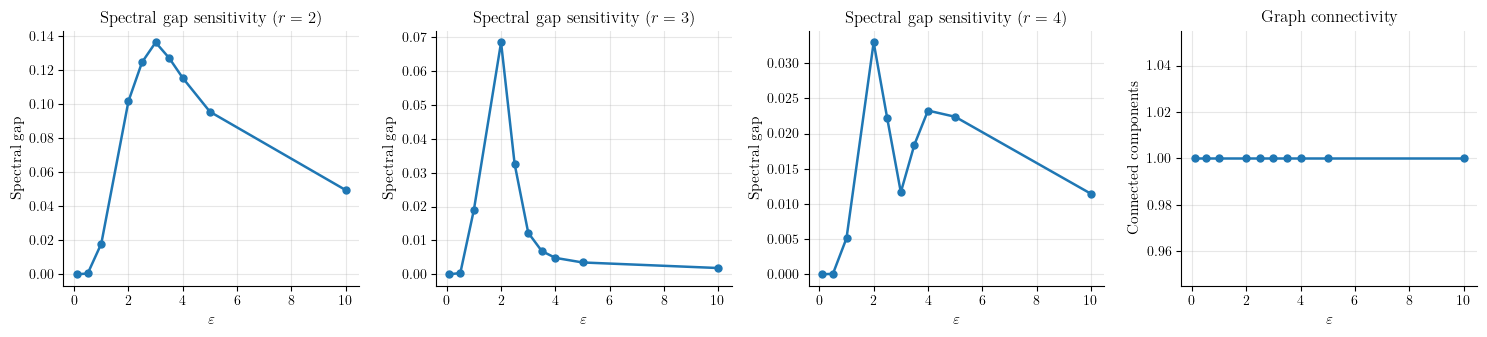

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))

axes[0].plot(eps_embedding_df["eps"], eps_embedding_df["spectral_gap_m1"], marker="o")
axes[0].set_xlabel(r"$\varepsilon$")
axes[0].set_ylabel("Spectral gap")
axes[0].set_title("Spectral gap sensitivity  ($r=2$)")
axes[0].grid(alpha=0.3)

axes[1].plot(eps_embedding_df["eps"], eps_embedding_df["spectral_gap"], marker="o")
axes[1].set_xlabel(r"$\varepsilon$")
axes[1].set_ylabel("Spectral gap")
axes[1].set_title("Spectral gap sensitivity ($r=3$)")
axes[1].grid(alpha=0.3)

axes[2].plot(eps_embedding_df["eps"], eps_embedding_df["spectral_gap_p1"], marker="o")
axes[2].set_xlabel(r"$\varepsilon$")
axes[2].set_ylabel("Spectral gap")
axes[2].set_title("Spectral gap sensitivity ($r=4$)")
axes[2].grid(alpha=0.3)

axes[3].plot(eps_embedding_df["eps"], eps_embedding_df["connected_components"], marker="o")
axes[3].set_xlabel(r"$\varepsilon$")
axes[3].set_ylabel("Connected components")
axes[3].set_title("Graph connectivity")
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

There is a very large spike at the embedding dimension $r=3$ when $\varepsilon=2$, this suggests that something isn't quite right. When we choose the embedding dimension $r=2$, we get a much more stable spectral gap plot with a spike at $\varepsilon=3$. There is also a very small gap between $\lambda_4$ and $\lambda_5$ when $\varepsilon=3$, which suggests that this could be a degenerate pair like what we saw in the toy problems for the sphere and two-torus.

All graphs remain connected for range of bandwidths which is good to see, it might mean that our value of $k$ is quite generous. I don't think this is an issue though.

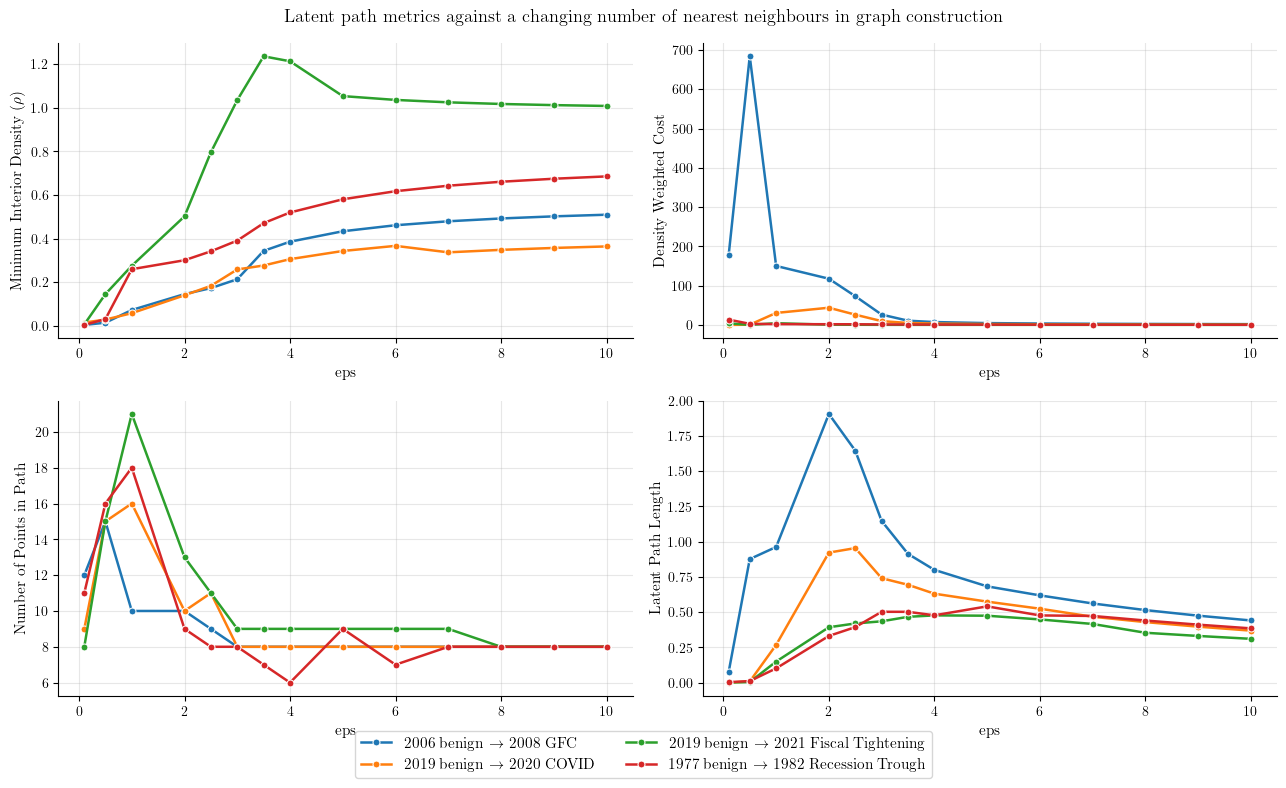

In [21]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['interior_minimum_density', 'density_weighted_cost', 'number_points', 'latent_path_length']

metric_names_clean = {
    "interior_minimum_density": r"Minimum Interior Density ($\rho$)",
    "density_weighted_cost": "Density Weighted Cost",
    "number_points": "Number of Points in Path",
    "latent_path_length": "Latent Path Length"}

path_df_plot = eps_path_df[eps_path_df["path_type"] != "ordinary graph"]
for i, metric in enumerate(metrics):
    sns.lineplot(data=path_df_plot, x='eps', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("./figures/robustness_k.pdf")
plt.show()

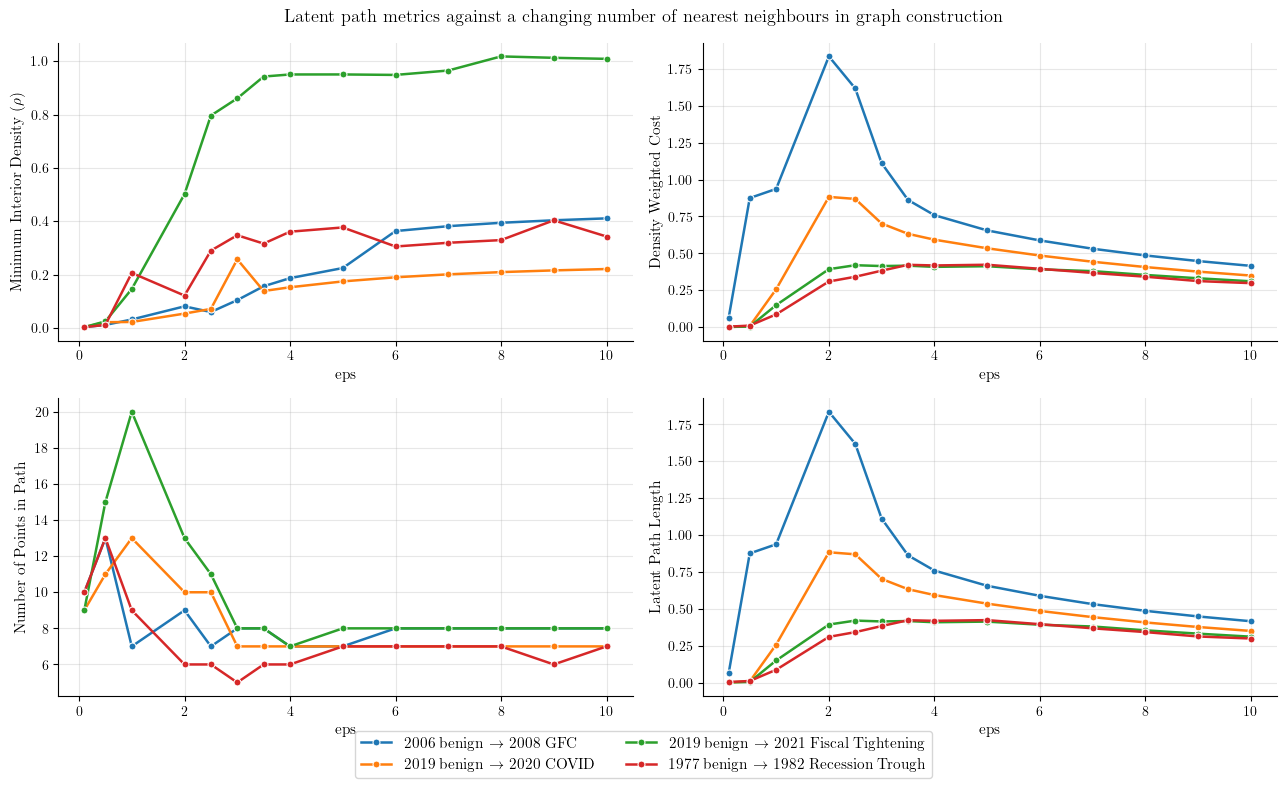

In [51]:
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_WD)
axes_flat = axes.flatten()

fig.suptitle("Latent path metrics against a changing number of nearest neighbours in graph construction")
metrics = ['interior_minimum_density', 'density_weighted_cost', 'number_points', 'latent_path_length']

metric_names_clean = {
    "interior_minimum_density": r"Minimum Interior Density ($\rho$)",
    "density_weighted_cost": "Density Weighted Cost",
    "number_points": "Number of Points in Path",
    "latent_path_length": "Latent Path Length"}

path_df_plot = eps_path_df[eps_path_df["path_type"] == "ordinary graph"]
for i, metric in enumerate(metrics):
    sns.lineplot(data=path_df_plot, x='eps', y=metric, hue='event_label', marker='o', palette='tab10', ax=axes_flat[i], legend=(i == 0))
    axes_flat[i].set_ylabel(metric_names_clean.get(metric, metric))
    axes_flat[i].grid(alpha=0.3)

handles, labels = axes_flat[0].get_legend_handles_labels()
axes_flat[0].get_legend().remove()

fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig("./figures/robustness_k.pdf")
plt.show()

#### Trying to figure out why there is such a big spike in the cost for $\varepsilon=0.5$ in the density-aware graph path for the 2008 GFC event

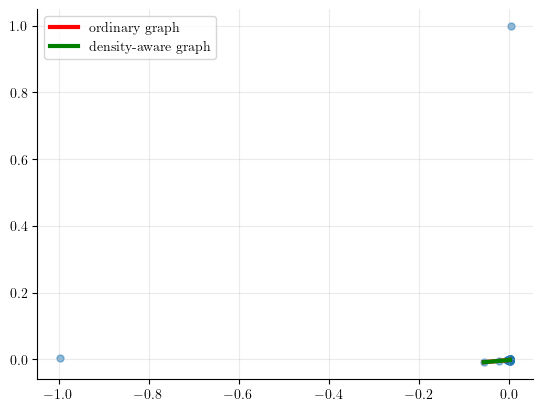

In [57]:
eps = 0.5

poi = [(path["coords"], path["path_type"]) for path in paths_eps if path["event"] == "2006 benign -> 2008 GFC" and path["eps"] == eps]
Psi_oi = embedding_store[eps]["Psi"]
Voi = embedding_store[eps]["V"]

plt.scatter(Psi_oi[:, 0], Psi_oi[:, 1], alpha=0.5)
plt.plot(poi[0][0][:, 0], poi[0][0][:, 1], label=poi[0][1], c="r", linewidth=3)
plt.plot(poi[1][0][:, 0], poi[1][0][:, 1], label=poi[1][1], c="g", linewidth=3)
# plt.xlim([-0.1, 0.005]); plt.ylim([-0.025, 0.025])
plt.legend()
plt.show()

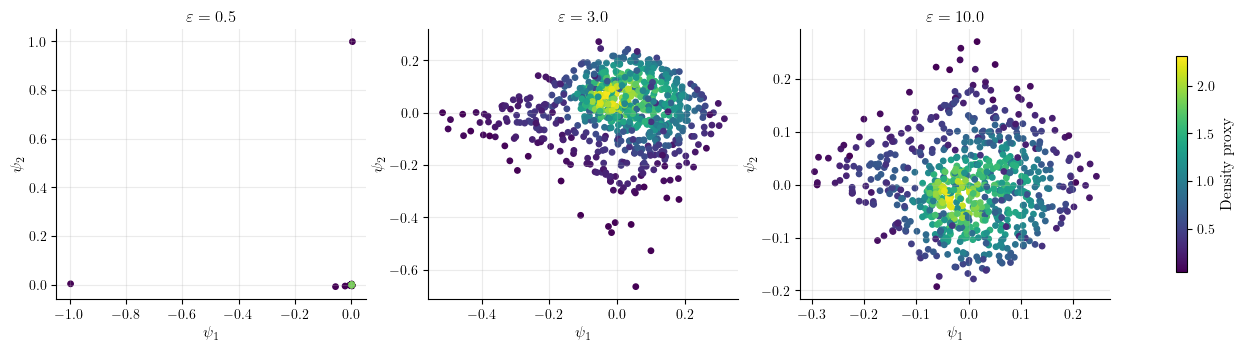

In [13]:
eps_to_plot = [0.5, 3.0, 10.0]

fig, axes = plt.subplots(1, len(eps_to_plot), figsize=(17, 3.5))

for ax, eps in zip(axes, eps_to_plot):

    Psi_eps = embedding_store[eps]["Psi"]
    rho_eps = embedding_store[eps]["rho"]

    scatter = ax.scatter(Psi_eps[:, 0], Psi_eps[:, 1], c=rho_eps, s=15)

    ax.set_title(rf"$\varepsilon={eps}$")
    ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$")

fig.colorbar(scatter, ax=axes, label="Density proxy", shrink=0.8)

plt.show()

### (iv) graph-degree density vs. KDE density

In [ ]:
def kde_density(Psi, bandwidth, kernel="gaussian", leave_one_out=False):
    n = len(Psi)
    if not leave_one_out:
        model = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(Psi)
        rho = np.exp(model.score_samples(Psi))
    else:
        rho = np.empty(n)
        for i in range(n):
            mask = np.arange(n) != i
            model = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(Psi[mask])
            rho[i] = np.exp(model.score_samples(Psi[i:i+1]))[0]

    rho = np.maximum(rho, 1e-6)
    rho /= rho.mean()
    return rho, -np.log(rho)

In [60]:
def compare_densities(rho_graph, rho_kde, sparse_q=0.10):
    rho_graph = np.asarray(rho_graph); rho_kde = np.asarray(rho_kde)
    spearman = spearmanr(rho_graph, rho_kde).statistic
    pearson_log = pearsonr(np.log(rho_graph), np.log(rho_kde)).statistic
    distance_corr = dcor.distance_correlation(np.asarray(rho_graph), np.asarray(rho_kde))

    n_sparse = max(1, int(np.ceil(sparse_q * len(rho_graph))))
    graph_sparse = set(np.argsort(rho_graph)[:n_sparse])
    kde_sparse = set(np.argsort(rho_kde)[:n_sparse])

    sparse_overlap = (len(graph_sparse & kde_sparse) / len(graph_sparse | kde_sparse))

    return {"spearman_density": spearman, "distance_density": distance_corr, "pearson_log_density": pearson_log, "sparse_set_jaccard": sparse_overlap}

In [96]:
gauss_rho, gauss_V = kde_density(Psi, bandwidth=h_dens*10)
compare_densities(rho, gauss_rho)

{'spearman_density': 0.9992231935358656,
 'distance_density': 0.9987985868304115,
 'pearson_log_density': 0.9984485064515412,
 'sparse_set_jaccard': 0.9230769230769231}

In [95]:
epan_rho, epan_V = kde_density(Psi, bandwidth=h_dens*10, kernel="epanechnikov")
compare_densities(rho, epan_rho)

{'spearman_density': 0.8996468915019452,
 'distance_density': 0.882191312508701,
 'pearson_log_density': 0.8587151249433802,
 'sparse_set_jaccard': 0.5}

In [94]:
th_rho, th_V = kde_density(Psi, bandwidth=h_dens*10, kernel="tophat")
compare_densities(rho, th_rho)

{'spearman_density': 0.9213693798034842,
 'distance_density': 0.9061405586584549,
 'pearson_log_density': 0.8967150415811682,
 'sparse_set_jaccard': 0.5}

In [97]:
# Existing graph-degree density
h_dens, _, (rho_graph, V_graph, _) = density_and_bandwidth(Psi)
# Gaussian KDE
rho_g, V_g = kde_density(Psi, bandwidth=h_dens*10)
# Epanechnikov density
rho_e, V_e = kde_density(Psi, bandwidth=h_dens*10, kernel="epanechnikov")
# Tophat density
rho_t, V_t = kde_density(Psi, bandwidth=h_dens*10, kernel="tophat")

density_methods = {"Graph degree": (rho_graph, V_graph), "Gaussian KDE": (rho_g, V_g), "Epanechnikov": (rho_e, V_e), "Tophat": (rho_t, V_t)}

In [105]:
rows = []; density_paths = {}

for event, (start_idx, end_idx) in pairs.items():
    density_paths[event] = {}

    idx_graph = graph_path(A_dist_sym, beta=0.0, V=V, start=start_idx, end=end_idx)
    rho_graph = rho[idx_graph]
    interior_density_graph = (rho_graph[1:-1] if len(rho_graph) > 2 else rho_graph)


    n_grid = len(idx_graph)
    gamma = linear_path(Psi, start_idx, end_idx, n_grid=n_grid)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    interior_density_lin = (rho_lin[1:-1] if len(rho_lin) > 2 else rho_lin)

    rows.append({"event": event, "density_method": "linear", "number_points": n_grid, "interior_minimum_density": interior_density_lin.min(),
                    "interior_mean_density": interior_density_lin.mean(), "latent_path_length": np.linalg.norm(Psi[end_idx] - Psi[start_idx])})
    
    rows.append({"event": event, "density_method": "ordinary graph", "number_points": n_grid, "interior_minimum_density": interior_density_graph.min(),
                    "interior_mean_density": interior_density_graph.mean(), "latent_path_length": latent_path_length(Psi[idx_graph])})
    density_paths[event]["ordinary graph"] = idx_graph

    for method, (rho_method, V_method) in density_methods.items():
        idx_path = graph_path(A_dist_sym, beta=BETA, V=V_method, start=start_idx, end=end_idx)
        path_density = rho_method[idx_path]
        interior_density = (path_density[1:-1] if len(path_density) > 2 else path_density)
        rows.append({ "event": event, "density_method": method, "number_points": len(idx_path),"interior_minimum_density": interior_density.min(),
                      "interior_mean_density": interior_density.mean(), "latent_path_length": latent_path_length(Psi[idx_path])})

        density_paths[event][method] = idx_path

density_comparison_df = pd.DataFrame(rows)
print(density_comparison_df.round(4).to_string(index=False))

                                event density_method  number_points  interior_minimum_density  interior_mean_density  latent_path_length
              2006 benign -> 2008 GFC         linear              8                    0.0019                 0.3128              1.0611
              2006 benign -> 2008 GFC ordinary graph              8                    0.1048                 1.2236              1.1114
              2006 benign -> 2008 GFC   Graph degree              8                    0.2133                 1.3090              1.1473
              2006 benign -> 2008 GFC   Gaussian KDE              8                    0.2066                 1.3157              1.1473
              2006 benign -> 2008 GFC   Epanechnikov              9                    0.4965                 1.3701              1.2286
              2006 benign -> 2008 GFC         Tophat             10                    0.3804                 1.5059              1.2666
            2019 benign -> 2020 COVID    

In [106]:
print("Interior minimum density for each path and each method")
density_comparison_df.pivot(index="event", columns="density_method", values="interior_minimum_density").round(4)

Interior minimum density for each path and each method


density_method,Epanechnikov,Gaussian KDE,Graph degree,Tophat,linear,ordinary graph
event,,,,,,
1977 benign -> 1982 Recession Trough,0.3368,0.4523,0.3907,0.2536,0.3090,0.3478
2006 benign -> 2008 GFC,0.4965,0.2066,0.2133,0.3804,0.0019,0.1048
2019 benign -> 2020 COVID,0.5184,0.2463,0.2582,0.3804,0.0398,0.2576
2019 benign -> 2021 Fiscal Tightening,1.4990,1.0150,1.0353,1.6486,0.7236,0.8604


These all look reasonably close to each other, with no method strictly dominating any other.

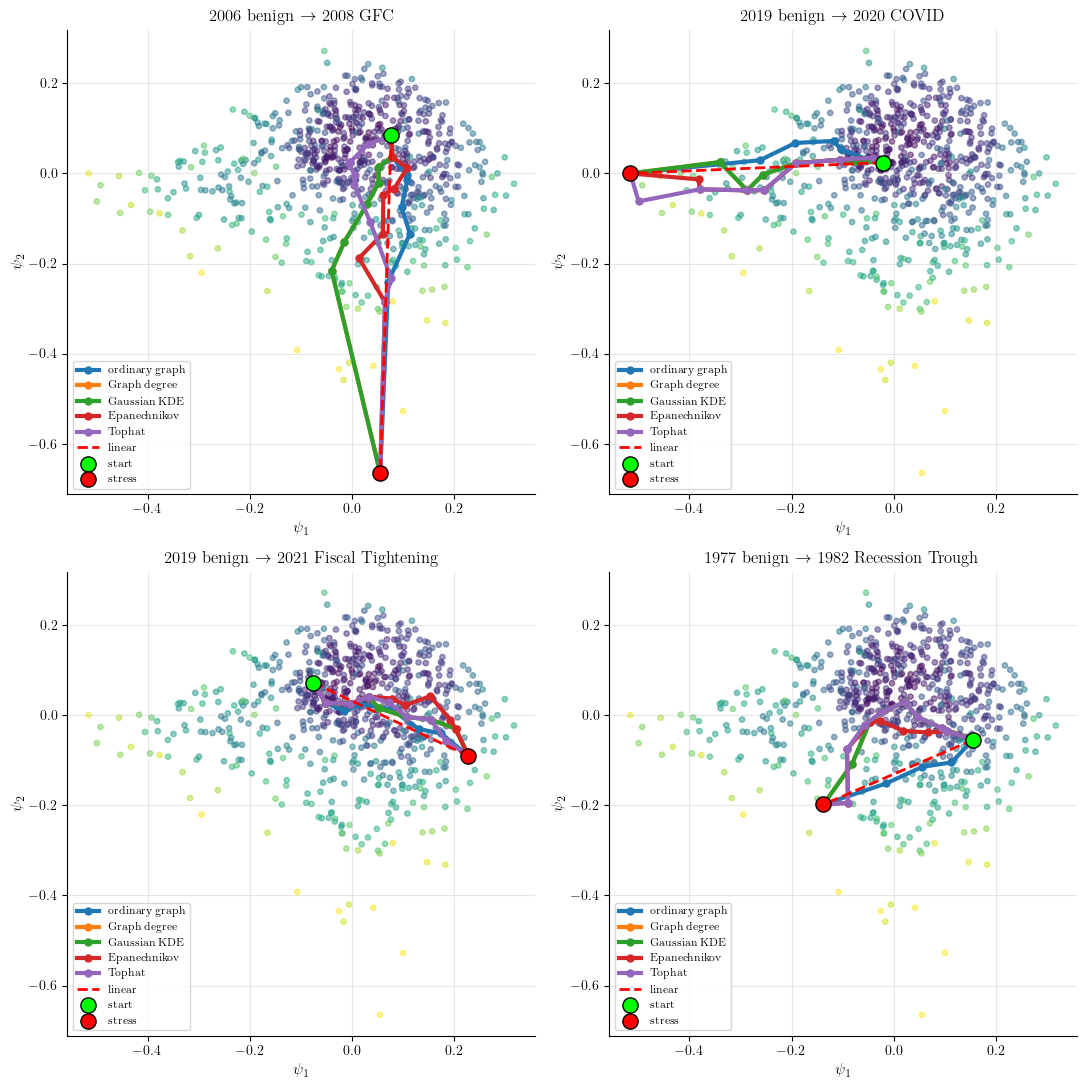

In [107]:
summary = []
fig, axes = plt.subplots(2, 2, figsize=ps.FIG_QUAD_SQ)

for ax, (name, (s, e)) in zip(axes.flatten(), pairs.items()):
    
    ax.scatter(Psi[:,0], Psi[:,1], c=V, s=15, cmap="viridis", alpha=.5)
    
    paths = []
    for dens_mtd, path in density_paths[name].items():
        P = Psi[path]; ax.plot(P[:,0], P[:,1], marker="o", ms=5, label=dens_mtd, linewidth=3)

    lin = np.linspace(Psi[s], Psi[e])
    ax.plot(lin[:,0], lin[:,1], "r--", lw=2, label="linear")
    
    ax.scatter(*Psi[s,:2], c="lime", s=120, ec="k", zorder=5, label="start")
    ax.scatter(*Psi[e,:2], c="red", s=120, ec="k", zorder=5, label="stress")

    ax.set_title(name.replace("->", r"$\rightarrow$")); ax.set_xlabel(r"$\psi_1$")
    ax.set_ylabel(r"$\psi_2$"); ax.legend(fontsize=8)
    ax.grid(alpha=.3)

plt.tight_layout()
plt.show()


These all look pretty similar, bandwidth selection is important for these. The gaussia_KDE has an automatic bandwidth selection process and I chose the bandwidth for Epanechnikov until the numbers looked nice.

#### (v) Compare against PCA latent-space interpolation

In [47]:
def lift_validation(z_hat, Z):
    nn = NearestNeighbors(n_neighbors=1)
    nn.fit(Z); dNN, _ = nn.kneighbors(z_hat)
    return dNN

In [61]:
# Load the quantile inverse
qt = joblib.load("models/quantile_transformer.joblib")

R_PCA = 3; N_GRID = 10

pca = PCA(n_components=R_PCA)
Psi_pca = pca.fit_transform(Z)

path_records = []

for event, (start_idx, end_idx) in pairs.items():
    # PCA path
    alpha = np.linspace(0, 1, N_GRID)[:, None]
    gamma_pca = ((1 - alpha) * Psi_pca[start_idx] + alpha * Psi_pca[end_idx])
    Z_pca_quantile = pca.inverse_transform(gamma_pca)
    Z_pca_real = qt.inverse_transform(Z_pca_quantile)
    pca_lift_val = lift_validation(Z_pca_quantile, Z)
    path_records.append({"event": event, "path_type": "PCA", "Z_lift_quantile": Z_pca_quantile, "Z_lift_real": Z_pca_real, "dNN": pca_lift_val})

    # Graph path
    idx_graph = graph_path(A_dist_sym, beta=BETA, V=V, start=start_idx, end=end_idx)
    if len(idx_graph) > 2: interior_density = rho[idx_graph][1:-1]
    else: interior_density = rho[idx_graph]
    path_records.append({"event": event, "path_type": "density_aware", "Z_lift_quantile": Z[idx_graph], "Z_lift_real": Z_real[idx_graph], "dNN": np.zeros(len(idx_graph))})

    # Linear lift using LNL
    n_grid = len(idx_graph)
    gamma = linear_path(Psi, start_idx, end_idx, n_grid)
    rho_lin, V_lin = latent_density_at_points(gamma, Psi, h_dens, scale)
    Z_lin_quantile = local_neighbourhood_lifting(Z, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    Z_lin_real = local_neighbourhood_lifting(Z_real, Psi, gamma, start_idx, end_idx, m=M_LIFT, tau=med_Dsq)
    lnl_lift_val = lift_validation(Z_lin_quantile, Z)
    path_records.append({"event": event, "path_type": "linear", "Z_lift_quantile": Z_lin_quantile, "Z_lift_real": Z_lin_real, "dNN": lnl_lift_val})

    # Observed path
    quantile_path = Z[start_idx:end_idx+1]
    real_path = Z_real[start_idx:end_idx+1]
    path_records.append({"event": event, "path_type": "observed", "Z_lift_quantile": quantile_path, "Z_lift_real": real_path, "dNN": np.zeros(len(real_path))})

Comparing $d_{NN}$ for LNL and PCA

In [49]:
nn = NearestNeighbors(n_neighbors=2).fit(Z)
historical_dNN, _ = nn.kneighbors(Z)
historical_dNN = historical_dNN[:, 1]

historical_median = np.median(historical_dNN)
historical_95 = np.quantile(historical_dNN, 0.95)

method_names = {"PCA": "PCA interpolation", "linear": "Diffusion linear (LNL)"}

rows = []

for record in path_records:
    if record["path_type"] not in method_names:
        continue

    dNN = np.asarray(record["dNN"]).ravel()

    # Exclude the fixed start and end points
    dNN_interior = dNN[1:-1] if len(dNN) > 2 else dNN

    rows.append({"event": record["event"], "method": method_names[record["path_type"]], 
                 "median_dNN": np.median(dNN_interior), "95%_dNN": np.quantile(dNN_interior, 0.95), "max_dNN": np.max(dNN_interior),
                 "% above historical 95%": (100 * np.mean(dNN_interior > historical_95))})

dNN_table = pd.DataFrame(rows)

(dNN_table.round(4))

,event,method,median_dNN,95%_dNN,max_dNN,% above historical 95%
0,2006 benign -> 2008 GFC,PCA interpolation,1.2164,1.3439,1.3828,0.0
1,2006 benign -> 2008 GFC,Diffusion linear (LNL),1.1396,1.2534,1.2774,0.0
2,2019 benign -> 2020 COVID,PCA interpolation,1.1114,1.2201,1.2303,0.0
3,2019 benign -> 2020 COVID,Diffusion linear (LNL),1.0654,1.1436,1.1456,0.0
4,2019 benign -> 2021 Fiscal Tightening,PCA interpolation,1.1861,1.2641,1.2756,0.0
5,2019 benign -> 2021 Fiscal Tightening,Diffusion linear (LNL),1.1794,1.1970,1.2001,0.0
6,1977 benign -> 1982 Recession Trough,PCA interpolation,1.1557,1.1722,1.1728,0.0
7,1977 benign -> 1982 Recession Trough,Diffusion linear (LNL),1.1230,1.1506,1.1554,0.0


In [50]:
historical_dNN_table = pd.DataFrame([{"reference": "Observed Z", "median_dNN": np.median(historical_dNN),
                                      "95%_dNN": np.quantile(historical_dNN, 0.95), "max_dNN": np.max(historical_dNN)}])

print(historical_dNN_table.round(4).to_string(index=False))

 reference  median_dNN  95%_dNN  max_dNN
Observed Z       1.468    1.784   2.1417


Both LNL and PCA look like they do a reasonable job at keeping the points in the observed data cloud. LNL usually performs better, but PCA has smaller nearest-neighbour distances for the `2019 benign -> 2020 COVID` paths.

Comparing real macro variables

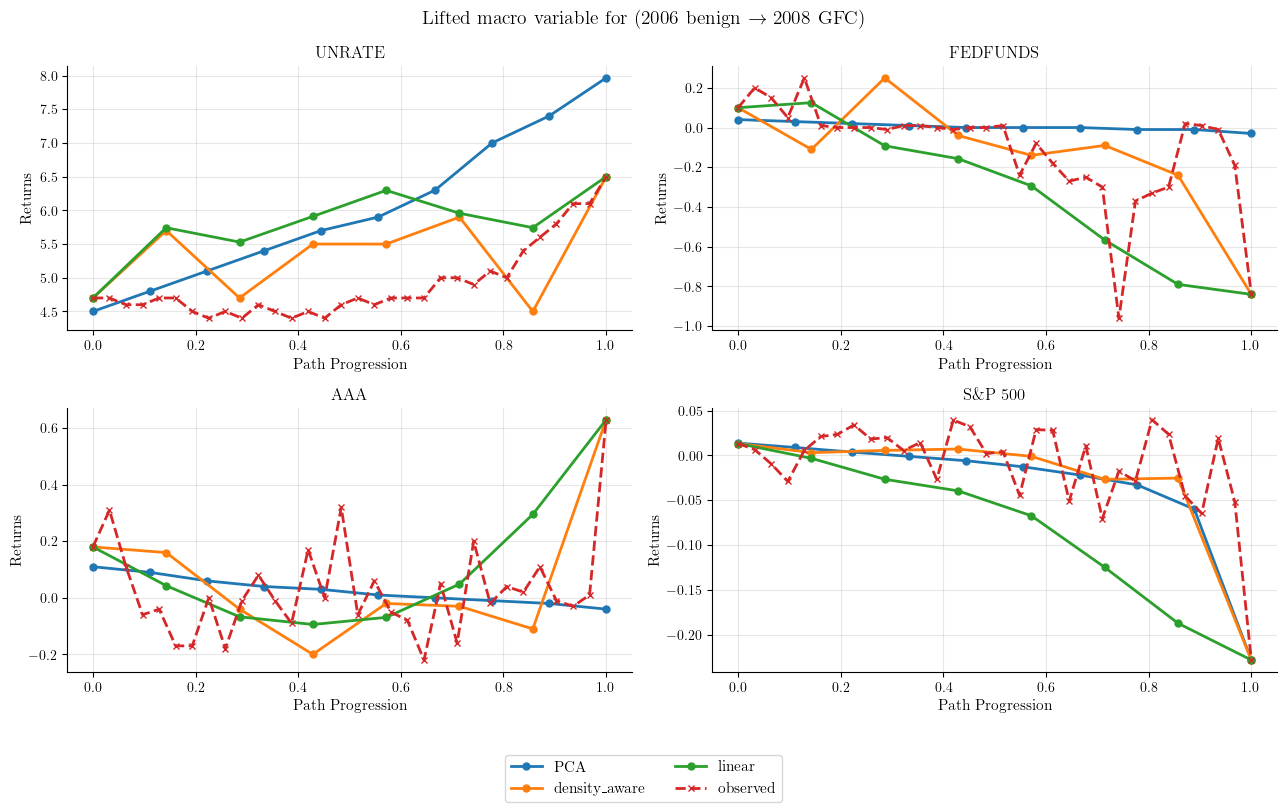

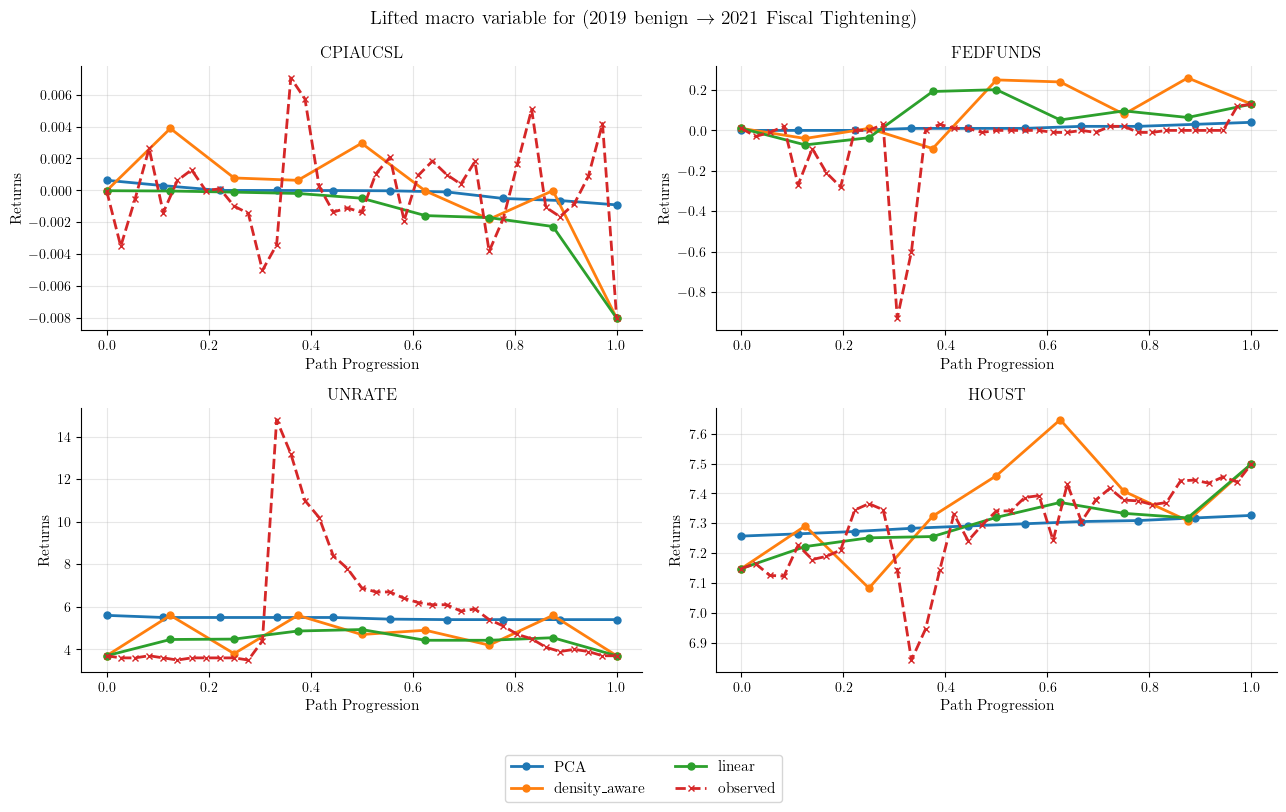

In [62]:
event_variables = {"2006 benign -> 2008 GFC": ["UNRATE", "FEDFUNDS", "AAA", "S&P 500"], 
                   "2019 benign -> 2021 Fiscal Tightening": ["CPIAUCSL", "FEDFUNDS", "UNRATE", "HOUST"]}

for event, selected_vars in event_variables.items():
    event_records = [rec for rec in path_records if rec["event"] == event]
    selected_idxs = [variables.get_loc(v) for v in selected_vars]

    n_vars = len(selected_vars); n_cols = 2
    n_rows = int(np.ceil(n_vars / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=ps.FIG_QUAD_WD, squeeze=False)
    axes_flat = axes.flatten()

    for path in event_records:
        path_type = path["path_type"]
        lifted_path = path["Z_lift_real"]
        x = np.linspace(0, 1, len(lifted_path))

        for i, var_idx in enumerate(selected_idxs):
            ax = axes_flat[i]
            if path_type == "observed":
                ax.plot(x, lifted_path[:, var_idx], marker="x", linestyle="--", linewidth=2, label=path_type)
            else:
                ax.plot(x, lifted_path[:, var_idx], marker="o", linewidth=2, label=path_type)

            ax.set_title(selected_vars[i].replace("&", "\&"), fontsize=12, fontweight='bold')
            ax.grid(alpha=0.3); ax.set_ylabel("Returns"); ax.set_xlabel("Path Progression")

    handles, labels = axes_flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.02))

    event_rename = event.replace("->", r"$\rightarrow$")
    plt.suptitle(rf'Lifted macro variable for ({event_rename})', fontsize=14, fontweight="bold")

    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

The PCA paths are very straight, suggesting that the points leave the manifold and are therefore not realistic. The PCA paths also don't reach the endpoints often. For the LNL the endpoints are hardcoded, however, as you can see in the GFC plots, the interior of the paths do tend towards the crisis endpoint, unlike PCA. From these plots, I would say that even linear paths from diffusion embeddings could be better than only using PCA. This might be a bias because I can see them linking both endpoints which is obviously what you would want to see. Should I hardcode endpoints for PCA?

The PCA path for S&P 500 in the GFC event looks very good, this must be because most of the variance of SP500 in GFC is governed by the first three PCA coordinates. Here the PCA path obviously has the LNL path beat in terms of staying on the manifold. I don't think I should really be comparing LNL and PCA like this, because as soon as we can do LNL in latent space, then we should use the density-aware paths anyway.

Main takeaway from this section is that PCA interpolation is similar to linear interpolation in diffusion coordinates in that it struggles to stay on the manifold. They are very straight because, unlike LNL, they are not pulled towards the manifold in any way. A main drawback I see is the fact that they don't reach the endpoints, and even if we did hardcode the endpoint, it would often look like a straight line with a very sharp kink towards the crisis point.

# Justification of 3d embedding

In [ ]:
R_VALUES = [2, 3, 4, 5]
REFERENCE_BETA = BETA

df = pd.read_parquet("./datasets/joint_df_quantile.parquet")
Z = df.to_numpy()[:, :-1]
dates = df.index; variables = df.columns[:-1]
pairs = {name: (dates.get_loc(pair[0]), dates.get_loc(pair[1])) for name, pair in endpoint_pairs.items()}

diff_full = diffusion_map(Z, eps=EPS_DIFFUSION, k=max(R_VALUES))
Psi_full = diff_full["Psi"]

def lnl_error(Psi, Z, m, tau):
    N = len(Z); Z_hat = np.zeros_like(Z, dtype=float)

    for i in range(N):
        mask = np.arange(N) != i
        nn = NearestNeighbors(n_neighbors=m).fit(Psi[mask])
        distances, indices = nn.kneighbors(Psi[i:i+1])

        d2 = distances[0]**2; weights = np.exp(-(d2 - d2.min()) / tau)
        weights /= weights.sum(); Z_hat[i] = weights @ Z[mask][indices[0]]

    residual = Z - Z_hat; residual_ss = np.sum(residual**2)
    total_ss = np.sum((Z - Z.mean(axis=0))**2)

    return {"lift_RMSE": np.sqrt(np.mean(residual**2)), 
            "rms_observation_error": np.sqrt(np.mean(np.sum(residual**2, axis=1))), 
            "variance_recovered": 1 - residual_ss / total_ss}


dimension_rows, path_rows, dimension_store = [], [], {}

for r in R_VALUES:
    Psi_r = Psi_full[:, :r]
    h_r, med_Dsq_r, (rho_r, V_r, scale_r) = density_and_bandwidth(Psi_r)

    A_r = kneighbors_graph(Psi_r, n_neighbors=K_GRAPH, mode="distance", include_self=False)
    A_r_sym = A_r.maximum(A_r.T)

    reconstruction = lnl_error(Psi_r, Z, m=M_LIFT, tau=med_Dsq_r)
    degree_r = np.asarray((A_r_sym > 0).sum(axis=1)).ravel()
    n_components_r = connected_components(A_r_sym, directed=False, return_labels=False)

    dimension_rows.append({"r": r, "lift_RMSE": reconstruction["lift_RMSE"], "variance_recovered_%": 100 * reconstruction["variance_recovered"],
                           "connected_components": n_components_r, "mean_degree": degree_r.mean(), "mean_edge_length": A_r_sym.data.mean(),
                           "median_edge_length": np.median(A_r_sym.data), "density_bandwidth": h_r})

    dimension_store[r] = {"Psi": Psi_r, "rho": rho_r, "V": V_r, "h": h_r, 
                          "scale": scale_r, "med_Dsq": med_Dsq_r, "A_dist_sym": A_r_sym}

    for event, (start_idx, end_idx) in pairs.items():
        for path_type, beta in {"ordinary": 0.0, "density-aware": BETA}.items():
            idx_path = graph_path(A_r_sym, beta=beta, V=V_r, start=start_idx, end=end_idx)

            if idx_path is None:
                raise RuntimeError(f"No path found for r={r}, event={event}.")

            coords = Psi_r[idx_path]
            interior_idx = idx_path[1:-1] if len(idx_path) > 2 else idx_path
            interior_density = rho_r[interior_idx]

            path_rows.append({"r": r, "event": event, "path_type": path_type, "number_points": len(idx_path),
                              "latent_path_length": latent_path_length(coords), "reference_beta_cost": density_weighted_cost(coords, V_r[idx_path], beta=REFERENCE_BETA),
                              "interior_minimum_density": interior_density.min(), "interior_mean_density": interior_density.mean()})

dimension_table = pd.DataFrame(dimension_rows)
path_dimension_table = pd.DataFrame(path_rows)

display(dimension_table.round(4))
display(path_dimension_table.round(4))

,r,lift_RMSE,variance_recovered_%,connected_components,mean_degree,mean_edge_length,median_edge_length,density_bandwidth
0,2,0.2384,31.9577,1,17.5962,0.0336,0.0264,0.0044
1,3,0.2256,39.0641,1,18.8856,0.0603,0.0492,0.0052
2,4,0.2129,45.7544,1,19.3674,0.0802,0.0690,0.0060
3,5,0.2103,47.0694,1,19.3486,0.0899,0.0781,0.0069


,r,event,path_type,number_points,latent_path_length,reference_beta_cost,interior_minimum_density,interior_mean_density
0,2,2006 benign -> 2008 GFC,ordinary,13,0.7604,25.6400,0.2016,1.0145
1,2,2006 benign -> 2008 GFC,density-aware,16,0.7793,21.5071,0.2563,0.9452
2,2,2019 benign -> 2020 COVID,ordinary,13,0.5052,5.3135,0.2466,0.9825
3,2,2019 benign -> 2020 COVID,density-aware,15,0.5215,4.8917,0.2147,1.0053
4,2,2019 benign -> 2021 Fiscal Tightening,ordinary,16,0.3486,0.3236,0.6330,1.5312
5,2,2019 benign -> 2021 Fiscal Tightening,density-aware,15,0.3535,0.3212,0.7518,1.5319
6,2,1977 benign -> 1982 Recession Trough,ordinary,10,0.3289,1.3146,0.3266,0.7460
7,2,1977 benign -> 1982 Recession Trough,density-aware,15,0.3804,1.2143,0.2755,1.0585
8,3,2006 benign -> 2008 GFC,ordinary,9,1.0802,38.3018,0.1706,1.1336
9,3,2006 benign -> 2008 GFC,density-aware,10,1.1211,25.4583,0.3120,1.3036


Adding the 3rd coordinate improves the variance recoved by roughly 7%, and adding the 4th coordinate further improves the variance recovered by roughly 7%. Adding the 5th coordinate only increases the variance recovered by just over 1%. This gives evidence to suggest we need more than 2 dimensions but less than 5. From this I am being led towards thinking that $r=4$ is a good choice.

For two paths, the density-aware path has a lower minimum density for $r=2$, however both of those paths have a higher mean density.

For all paths, both $r=3$ and $r=4$ has the minimum density strictly increasing between the ordinary path and density-aware path. For $r=5$, the relation is not strict, there is an example where the paths are the same for both, meaning min density does not increase. This is not necessarily bad. This relates to the fact that the number of elements in a path for $r=5$ is usually lower than that for $r<5$, this maybe suggests unrealistic jumps.

Both $r=3$ and $r=4$ look to be reasonable choices. I don't see a reason, so far, to choose $r=3$ over $r=4$.

#### Near collision diagnostic

In [ ]:
def collision_diagnostic(Psi_full, dates=None, base_dims=(2, 3, 4),
                         collision_quantile=0.01, min_index_gap=12):
    n = len(Psi_full)
    i_all, j_all = np.triu_indices(n, k=1)

    keep = np.abs(i_all - j_all) > min_index_gap
    i, j = i_all[keep], j_all[keep]

    summaries, pair_tables = [], {}

    for base_dim in base_dims:
        base_distance = np.linalg.norm(Psi_full[i, :base_dim] - Psi_full[j, :base_dim], axis=1)
        new_distance = np.linalg.norm(Psi_full[i, :base_dim+1] - Psi_full[j, :base_dim+1], axis=1)

        added_separation = np.abs(Psi_full[i, base_dim] - Psi_full[j, base_dim])
        added_sd = np.std(Psi_full[:, base_dim], ddof=1)
        added_separation_std = added_separation / max(added_sd, 1e-12)

        collision_threshold = np.quantile(base_distance, collision_quantile)
        near_collision = base_distance <= collision_threshold

        new_quantiles = [0.01, 0.05, 0.10]; leaving_threshold = []
        for quantile in new_quantiles:
            new_threshold = np.quantile(new_distance, quantile)
            fraction_above_threshold = np.mean(new_distance[near_collision] > new_threshold)
            leaving_threshold.append(fraction_above_threshold)

        all_median = np.median(added_separation_std)
        near_values = added_separation_std[near_collision]

        summaries.append({"comparison": f"{base_dim}D -> {base_dim + 1}D", "collision_distance_threshold": collision_threshold, "number_near_collisions": near_collision.sum(),
                          "percent_leaving_bottom_1pct": leaving_threshold[0], "percent_leaving_bottom_5pct": leaving_threshold[1], "percent_leaving_bottom_10pct": leaving_threshold[2],
                          "median_added_separation_SD": np.median(near_values), "all_pairs_median_added_separation_SD": all_median})

        pair_table = pd.DataFrame({"i": i, "j": j, "base_distance": base_distance, "new_distance": new_distance,
                                    "added_separation": added_separation, "added_separation_SD": added_separation_std,
                                    "near_collision": near_collision})

        if dates is not None:
            date_array = np.asarray(dates)
            pair_table["date_i"] = date_array[i]
            pair_table["date_j"] = date_array[j]

        pair_tables[base_dim] = pair_table

    return pd.DataFrame(summaries), pair_tables


In [13]:
collision_summary, collision_pairs = collision_diagnostic(
    Psi_full,
    dates=dates,
    base_dims=(2, 3, 4),
    collision_quantile=0.01,
    min_index_gap=12
)

display(collision_summary.round(4))

,comparison,collision_distance_threshold,number_near_collisions,percent_leaving_bottom_1pct,percent_leaving_bottom_5pct,percent_leaving_bottom_10pct,median_added_separation_SD,all_pairs_median_added_separation_SD
0,2D -> 3D,0.0243,2669,0.5804,0.3106,0.1855,0.6902,0.8400
1,3D -> 4D,0.0446,2669,0.4953,0.2076,0.1008,0.7428,0.9322
2,4D -> 5D,0.0643,2669,0.2319,0.0195,0.0026,0.4277,0.9330


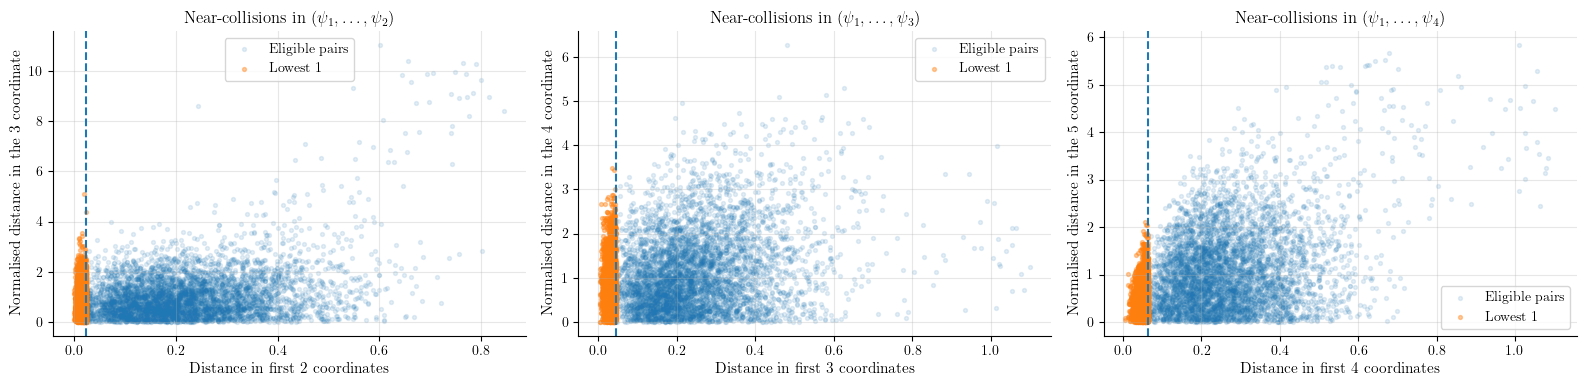

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, base_dim in zip(axes, [2, 3, 4]):
    pair_df = collision_pairs[base_dim]
    background = pair_df.sample(min(5000, len(pair_df)), random_state=0)
    collisions = pair_df[pair_df["near_collision"]]

    ax.scatter(background["base_distance"], background["added_separation_SD"], s=8, alpha=0.12, label="Eligible pairs")
    ax.scatter(collisions["base_distance"], collisions["added_separation_SD"], s=8, alpha=0.4, label="Lowest 1% distance")
    threshold = collisions["base_distance"].max(); ax.axvline(threshold, linestyle="--", linewidth=1.5)

    ax.set_title(rf"Near-collisions in $(\psi_1,\ldots,\psi_{base_dim})$")
    ax.set_xlabel(f"Distance in first {base_dim} coordinates")
    ax.set_ylabel(rf"Normalised distance in the {base_dim + 1} coordinate")
    ax.grid(alpha=0.3); ax.legend()

plt.tight_layout()
plt.show()

These plots are not as conclusive as my last test, but they do show that the standard deviation along the added coordinate is higher in the first two plots for the near-collision points. It is also interesting to see that for the outlier points, adding the third coordinate lets the outliers really express themselves, now some of them are 10 standard deviations away in the third coordinate. The similar effect is observed when adding the 4th coordinate to a slighly lesser extent, and there is not a crazy difference in the outliers; this is potentially a good point which seperates $r=3$ and $r=4$. For $r=3$ and $r=4$, the standard deviation of the near-collision points seemed to be quitesimilar to the rest of the points, unlike in the third plot for $r=5$, where the points seem to stay close together, indicating that adding $\psi_5$ is not useful. 